# Комплексное сравнение всех моделей детекции фейковых новостей

Оцениваем качество всех моделей на **in-distribution hold-out** выборке из `ready_dataset.csv` (SEED=42, test_size=0.1, stratify=label) — том же сплите, что использовался при обучении RuBERT / LLM V1 / V2 / V3. Ни одна модель не видела эти примеры во время обучения, распределение полностью совпадает с обучающим.

**Классические модели:**
- Logistic Regression + TF-IDF
- Naive Bayes + TF-IDF
- Random Forest + TF-IDF
- Logistic Regression + Word2Vec
- Random Forest + Word2Vec

**Трансформеры:**
- RuBERT (fine-tuned)

**LLM-подходы:**
- V1: ruGPT-3 + LoRA (r=16)
- V2: Frozen GPT + Sklearn
- V3: ruGPT-3 + LoRA Max (r=32)
- V3 Tuned: ruGPT-3 + LoRA Max (r=64, взвешенный loss, class_weight=[1.3, 1.0])

In [1]:
import os, sys, re, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from gensim.models import KeyedVectors
import joblib
import nltk

warnings.filterwarnings("ignore")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
print("Working dir:", os.getcwd())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
sns.set_style("whitegrid")

c:\Users\pozoy\Desktop\MISIS\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working dir: c:\Users\pozoy\Desktop\MISIS\final
Device: cpu


## 1. Загрузка тестовых данных

In [2]:
from sklearn.model_selection import train_test_split

# ────────────────────────────────────────────────────────────
# Тестовая выборка — in-distribution hold-out из ready_dataset
# Используем ТОТ ЖЕ split (SEED=42, test_size=0.1, stratify=label),
# что применялся при обучении RuBERT / LLM V1 / V2 / __TEMP_V2__.
# Это корректное сравнение: данные одного распределения,
# ни одна модель их не видела в train.
# ────────────────────────────────────────────────────────────

SEED = 42
DATA_PATH = "data/ready_dataset.csv"

df = pd.read_csv(DATA_PATH)
df = df[["headline_clean", "body_clean", "label"]].dropna()
df["headline_clean"] = df["headline_clean"].astype(str).str.strip()
df["body_clean"]     = df["body_clean"].astype(str).str.strip()
df = df[(df["headline_clean"] != "") & (df["body_clean"] != "")]
df["label"] = pd.to_numeric(df["label"], errors="coerce").astype(int)
df = df.reset_index(drop=True)

_, test_df = train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df["label"],
)
test_df = test_df.reset_index(drop=True)

y_true    = test_df["label"].values
headlines = test_df["headline_clean"].astype(str).tolist()
bodies    = test_df["body_clean"].astype(str).tolist()

print(f"Тестовая выборка: {len(test_df)} примеров (in-distribution hold-out)")
print(f"  Реальные (1): {(y_true == 1).sum()}")
print(f"  Фейки    (0): {(y_true == 0).sum()}")

# Препроцессинг для классических моделей (TF-IDF / Word2Vec)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("russian"))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r"http\S+|www\S+|https\S+", "", t)
    t = re.sub(r"\S+@\S+", "", t)
    t = re.sub(r"<.*?>", "", t)
    t = re.sub(r"[^а-яёa-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return " ".join(w for w in t.split() if w not in STOPWORDS and len(w) > 2)


Тестовая выборка: 441 примеров (in-distribution hold-out)
  Реальные (1): 219
  Фейки    (0): 222


## 2. Загрузка всех моделей

In [3]:
# --- TF-IDF ---
tfidf_vec = pickle.load(open("models/tfidf_vectorizer_tf.pkl", "rb"))
tfidf_lr = pickle.load(open("models/logistic_regression_model_tf.pkl", "rb"))
tfidf_nb = pickle.load(open("models/naive_bayes_model_tf.pkl", "rb"))
tfidf_rf = pickle.load(open("models/random_forest_model_tf.pkl", "rb"))
print("TF-IDF модели загружены")

# --- Word2Vec ---
w2v_kv = KeyedVectors.load("models/w2v_vectors.kv")
w2v_lr = pickle.load(open("models/logisticregression_model.pkl", "rb"))
w2v_rf = pickle.load(open("models/randomforest_model.pkl", "rb"))
print("Word2Vec модели загружены")

# --- RuBERT ---
rubert_tok = AutoTokenizer.from_pretrained("models/rubert/best_model")
rubert_mdl = AutoModelForSequenceClassification.from_pretrained("models/rubert/best_model").to(DEVICE)
rubert_mdl.eval()
print("RuBERT загружен")

# --- LLM V1: ruGPT-3 + LoRA ---
from peft import PeftModel
GPT_BASE = "ai-forever/rugpt3small_based_on_gpt2"

v1_tok = AutoTokenizer.from_pretrained("models/llm/rugpt3_lora")
v1_tok.padding_side = "left"
v1_base = AutoModelForSequenceClassification.from_pretrained(GPT_BASE, num_labels=2)
v1_base.config.pad_token_id = v1_tok.pad_token_id
v1_mdl = PeftModel.from_pretrained(v1_base, "models/llm/rugpt3_lora").merge_and_unload().to(DEVICE)
v1_mdl.eval()
print("LLM V1 загружен")

# --- LLM V2: Frozen GPT + Sklearn ---
v2_tok = AutoTokenizer.from_pretrained(GPT_BASE)
if v2_tok.pad_token is None:
    v2_tok.pad_token = v2_tok.eos_token
v2_enc = AutoModel.from_pretrained(GPT_BASE).to(DEVICE)
v2_enc.eval()
for p in v2_enc.parameters():
    p.requires_grad = False
v2_scaler = joblib.load("models/llm_v2/scaler.pkl")
v2_classifiers = joblib.load("models/llm_v2/all_classifiers.pkl")
print("LLM V2 загружен")

# --- LLM V3: ruGPT-3 + LoRA Max ---
v3_tok = AutoTokenizer.from_pretrained("./models/llm_v3/lora_adapter")
v3_tok.padding_side = "left"
if v3_tok.pad_token is None:
    v3_tok.pad_token = v3_tok.eos_token
v3_base = AutoModelForSequenceClassification.from_pretrained(GPT_BASE, num_labels=2)
v3_base.config.pad_token_id = v3_tok.pad_token_id
v3_mdl = PeftModel.from_pretrained(v3_base, "./models/llm_v3/lora_adapter").merge_and_unload().to(DEVICE)
v3_mdl.eval()
print("LLM V3 загружен")

# --- LLM V3 Tuned: ruGPT-3 + LoRA (r=64, взвешенный loss) ---
v3t_tok = AutoTokenizer.from_pretrained("./models/llm_v3_tuned/lora_adapter")
v3t_tok.padding_side = "left"
if v3t_tok.pad_token is None:
    v3t_tok.pad_token = v3t_tok.eos_token
v3t_base = AutoModelForSequenceClassification.from_pretrained(GPT_BASE, num_labels=2)
v3t_base.config.pad_token_id = v3t_tok.pad_token_id
v3t_mdl = PeftModel.from_pretrained(v3t_base, "./models/llm_v3_tuned/lora_adapter").merge_and_unload().to(DEVICE)
v3t_mdl.eval()
print("LLM V3 Tuned загружен")

print("\nВсе модели загружены успешно!")

TF-IDF модели загружены
Word2Vec модели загружены
RuBERT загружен


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LLM V1 загружен
LLM V2 загружен


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LLM V3 загружен


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LLM V3 Tuned загружен

Все модели загружены успешно!


## 3. Прогнозы на тестовой выборке

In [4]:
from tqdm import tqdm

# ────────────────────────────────────────────────────────────
# Вспомогательные функции
# ────────────────────────────────────────────────────────────

def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    return np.vstack(vecs).mean(axis=0) if vecs else np.zeros(kv_model.vector_size, dtype=np.float32)

# ────────────────────────────────────────────────────────────
# TF-IDF предсказания
# ────────────────────────────────────────────────────────────
print("TF-IDF предсказания...")
h_clean = [preprocess_text(h) for h in headlines]
b_clean = [preprocess_text(b) for b in bodies]
X_tfidf = tfidf_vec.transform([f"{h} {b}" for h, b in zip(h_clean, b_clean)])

preds_tfidf_lr = tfidf_lr.predict(X_tfidf)
probs_tfidf_lr = tfidf_lr.predict_proba(X_tfidf)[:, 1]

preds_tfidf_nb = tfidf_nb.predict(X_tfidf)
probs_tfidf_nb = tfidf_nb.predict_proba(X_tfidf)[:, 1]

preds_tfidf_rf = tfidf_rf.predict(X_tfidf)
probs_tfidf_rf = tfidf_rf.predict_proba(X_tfidf)[:, 1]
print("  Готово")

# ────────────────────────────────────────────────────────────
# Word2Vec предсказания
# ────────────────────────────────────────────────────────────
print("Word2Vec предсказания...")
w2v_feats = []
for h, b in zip(h_clean, b_clean):
    htoks = h.split()[:150]
    btoks = b.split()[:150]
    h_vec = doc_vector(htoks, w2v_kv)
    b_vec = doc_vector(btoks, w2v_kv)
    cos_sim = float(np.dot(h_vec, b_vec) / max(np.linalg.norm(h_vec) * np.linalg.norm(b_vec), 1e-8))
    jacc = len(set(htoks) & set(btoks)) / max(1, len(set(htoks) | set(btoks)))
    ovr = len(set(htoks) & set(btoks)) / max(1, len(set(htoks)))
    l2 = float(np.linalg.norm(h_vec - b_vec))
    feat = np.hstack([h_vec, b_vec, np.abs(h_vec - b_vec), h_vec * b_vec, [cos_sim, jacc, ovr, l2]])
    w2v_feats.append(feat)
X_w2v = np.array(w2v_feats)

preds_w2v_lr = w2v_lr.predict(X_w2v)
probs_w2v_lr = w2v_lr.predict_proba(X_w2v)[:, 1]

preds_w2v_rf = w2v_rf.predict(X_w2v)
probs_w2v_rf = w2v_rf.predict_proba(X_w2v)[:, 1]
print("  Готово")

TF-IDF предсказания...
  Готово
Word2Vec предсказания...
  Готово


In [5]:
# ────────────────────────────────────────────────────────────
# RuBERT предсказания
# ────────────────────────────────────────────────────────────
print("RuBERT предсказания...")
preds_rubert = []
probs_rubert = []

with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="RuBERT"):
        enc = rubert_tok(f"{h} {b}", truncation=True, padding="max_length", max_length=256, return_tensors="pt")
        out = rubert_mdl(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_rubert.append(int(np.argmax(p)))
        probs_rubert.append(float(p[1]))

preds_rubert = np.array(preds_rubert)
probs_rubert = np.array(probs_rubert)
print("  Готово")

RuBERT предсказания...


RuBERT: 100%|██████████| 441/441 [02:18<00:00,  3.18it/s]

  Готово


In [6]:
# ────────────────────────────────────────────────────────────
# LLM V1: ruGPT-3 + LoRA
# ────────────────────────────────────────────────────────────
print("LLM V1 предсказания...")
preds_v1 = []
probs_v1 = []

with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="LLM V1"):
        enc = v1_tok(f"{h} | {b}", truncation=True, padding="max_length", max_length=256, return_tensors="pt")
        out = v1_mdl(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_v1.append(int(np.argmax(p)))
        probs_v1.append(float(p[1]))

preds_v1 = np.array(preds_v1)
probs_v1 = np.array(probs_v1)
print("  Готово")

# ────────────────────────────────────────────────────────────
# LLM V2: Frozen GPT + Sklearn
# ────────────────────────────────────────────────────────────
print("LLM V2 предсказания...")
preds_v2 = []
probs_v2 = []

with torch.inference_mode():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="LLM V2"):
        def encode_v2(text):
            enc = v2_tok(str(text).strip(), truncation=True, max_length=64, padding=True, return_tensors="pt")
            hidden = v2_enc(input_ids=enc["input_ids"].to(DEVICE),
                            attention_mask=enc["attention_mask"].to(DEVICE)).last_hidden_state
            mf = enc["attention_mask"].to(DEVICE).unsqueeze(-1).float()
            return (hidden * mf).sum(1) / mf.sum(1).clamp(min=1e-9)

        h_emb = encode_v2(h)
        b_emb = encode_v2(b)
        feats = torch.cat([h_emb, b_emb, (h_emb - b_emb).abs(), h_emb * b_emb], dim=-1).cpu().numpy()
        feats_scaled = v2_scaler.transform(feats)
        prob = np.zeros(2)
        for _, clf in v2_classifiers.items():
            prob += clf.predict_proba(feats_scaled)[0]
        prob /= len(v2_classifiers)
        pred = int(np.argmax(prob))
        preds_v2.append(pred)
        probs_v2.append(float(prob[1]))

preds_v2 = np.array(preds_v2)
probs_v2 = np.array(probs_v2)
print("  Готово")

# ────────────────────────────────────────────────────────────
# LLM V3: ruGPT-3 + LoRA Max
# ────────────────────────────────────────────────────────────
print("LLM V3 предсказания...")
preds_v3 = []
probs_v3 = []

with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="LLM V3"):
        enc = v3_tok(f"{h} | {b}", truncation=True, padding="max_length", max_length=256, return_tensors="pt")
        out = v3_mdl(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_v3.append(int(np.argmax(p)))
        probs_v3.append(float(p[1]))

preds_v3 = np.array(preds_v3)
probs_v3 = np.array(probs_v3)
print("  Готово")

# ────────────────────────────────────────────────────────────
# LLM V3 Tuned: ruGPT-3 + LoRA (r=64, взвешенный loss)
# ────────────────────────────────────────────────────────────
print("LLM V3 Tuned предсказания...")
preds_v3t = []
probs_v3t = []

with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="LLM V3T"):
        enc = v3t_tok(f"{h} | {b}", truncation=True, padding="max_length", max_length=512, return_tensors="pt")
        out = v3t_mdl(input_ids=enc["input_ids"].to(DEVICE), attention_mask=enc["attention_mask"].to(DEVICE))
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_v3t.append(int(np.argmax(p)))
        probs_v3t.append(float(p[1]))

preds_v3t = np.array(preds_v3t)
probs_v3t = np.array(probs_v3t)
print("  Готово")

print("\nВсе предсказания получены!")

LLM V1 предсказания...


LLM V1: 100%|██████████| 441/441 [02:45<00:00,  2.67it/s]


  Готово
LLM V2 предсказания...


LLM V2: 100%|██████████| 441/441 [01:22<00:00,  5.34it/s]


  Готово
LLM V3 предсказания...


LLM V3: 100%|██████████| 441/441 [02:57<00:00,  2.49it/s]


  Готово
LLM V3 Tuned предсказания...


LLM V3T: 100%|██████████| 441/441 [05:51<00:00,  1.25it/s]

  Готово

Все предсказания получены!


## 4. Сводная таблица метрик

In [7]:
# Собираем все результаты в единый словарь
all_models = {
    "LR + TF-IDF":            {"preds": preds_tfidf_lr, "probs": probs_tfidf_lr, "category": "Классическая"},
    "NB + TF-IDF":            {"preds": preds_tfidf_nb, "probs": probs_tfidf_nb, "category": "Классическая"},
    "RF + TF-IDF":            {"preds": preds_tfidf_rf, "probs": probs_tfidf_rf, "category": "Классическая"},
    "LR + Word2Vec":          {"preds": preds_w2v_lr,   "probs": probs_w2v_lr,   "category": "Классическая"},
    "RF + Word2Vec":          {"preds": preds_w2v_rf,   "probs": probs_w2v_rf,   "category": "Классическая"},
    "RuBERT":                 {"preds": preds_rubert,    "probs": probs_rubert,    "category": "Трансформер"},
    "ruGPT-3+LoRA (V1)":     {"preds": preds_v1,        "probs": probs_v1,        "category": "LLM"},
    "FrozenGPT+Sk (V2)":     {"preds": preds_v2,        "probs": probs_v2,        "category": "LLM"},
    "ruGPT-3+LoRA (V3)":     {"preds": preds_v3,        "probs": probs_v3,        "category": "LLM"},
    "ruGPT-3+LoRA (V3T)":    {"preds": preds_v3t,       "probs": probs_v3t,       "category": "LLM"},
}

rows = []
for name, d in all_models.items():
    rows.append({
        "Модель": name,
        "Категория": d["category"],
        "Accuracy": accuracy_score(y_true, d["preds"]),
        "F1": f1_score(y_true, d["preds"], average="weighted"),
        "Precision": precision_score(y_true, d["preds"], average="weighted"),
        "Recall": recall_score(y_true, d["preds"], average="weighted"),
    })

results_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df.index = range(1, len(results_df) + 1)
results_df.style.format({
    "Accuracy": "{:.4f}", "F1": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}"
}).highlight_max(subset=["Accuracy", "F1", "Precision", "Recall"], color="#2d5f2d")

,Модель,Категория,Accuracy,F1,Precision,Recall
1,RuBERT,Трансформер,0.9819,0.9819,0.9819,0.9819
2,ruGPT-3+LoRA (V3T),LLM,0.9705,0.9705,0.9713,0.9705
3,LR + TF-IDF,Классическая,0.9660,0.9660,0.9671,0.9660
4,RF + TF-IDF,Классическая,0.9637,0.9637,0.9643,0.9637
5,ruGPT-3+LoRA (V1),LLM,0.9569,0.9569,0.9585,0.9569
6,ruGPT-3+LoRA (V3),LLM,0.9546,0.9546,0.9565,0.9546
7,RF + Word2Vec,Классическая,0.9524,0.9524,0.9531,0.9524
8,NB + TF-IDF,Классическая,0.9501,0.9501,0.9519,0.9501
9,LR + Word2Vec,Классическая,0.9320,0.9319,0.9325,0.9320
10,FrozenGPT+Sk (V2),LLM,0.8821,0.8819,0.8853,0.8821


## 5. Сравнение всех моделей — столбчатые диаграммы

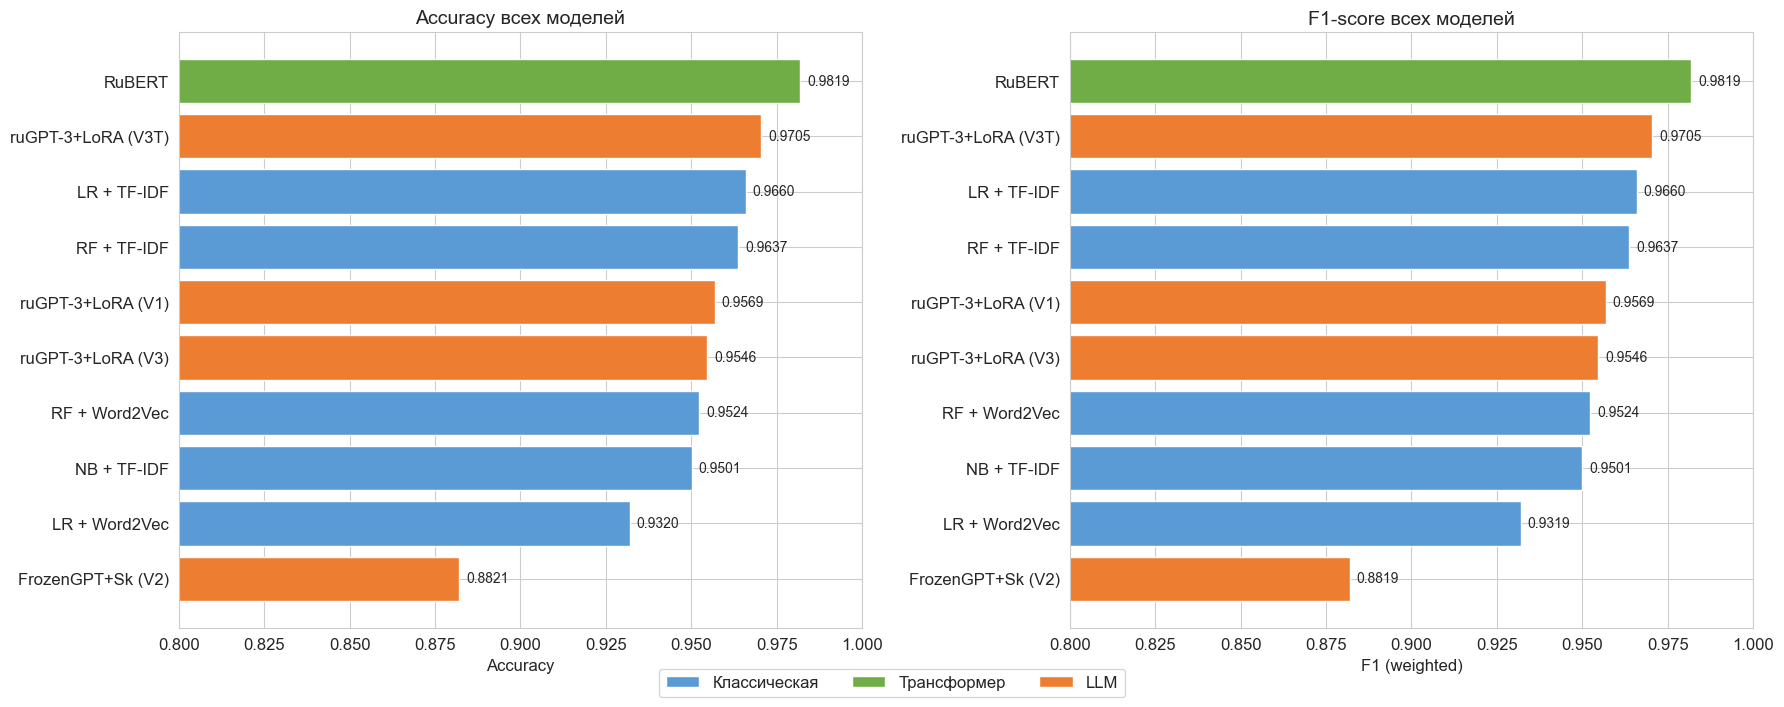

In [8]:
# Accuracy и F1 для всех моделей
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_sorted = results_df.sort_values("Accuracy", ascending=True)
colors = {"Классическая": "#5B9BD5", "Трансформер": "#70AD47", "LLM": "#ED7D31"}
bar_colors = [colors[c] for c in df_sorted["Категория"]]

axes[0].barh(df_sorted["Модель"], df_sorted["Accuracy"], color=bar_colors)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy всех моделей")
axes[0].set_xlim(0.8, 1.0)
for i, (val, name) in enumerate(zip(df_sorted["Accuracy"], df_sorted["Модель"])):
    axes[0].text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=10)

axes[1].barh(df_sorted["Модель"], df_sorted["F1"], color=bar_colors)
axes[1].set_xlabel("F1 (weighted)")
axes[1].set_title("F1-score всех моделей")
axes[1].set_xlim(0.8, 1.0)
for i, (val, name) in enumerate(zip(df_sorted["F1"], df_sorted["Модель"])):
    axes[1].text(val + 0.002, i, f"{val:.4f}", va="center", fontsize=10)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("assets/all_models_accuracy_f1.png", dpi=150, bbox_inches="tight")
plt.show()

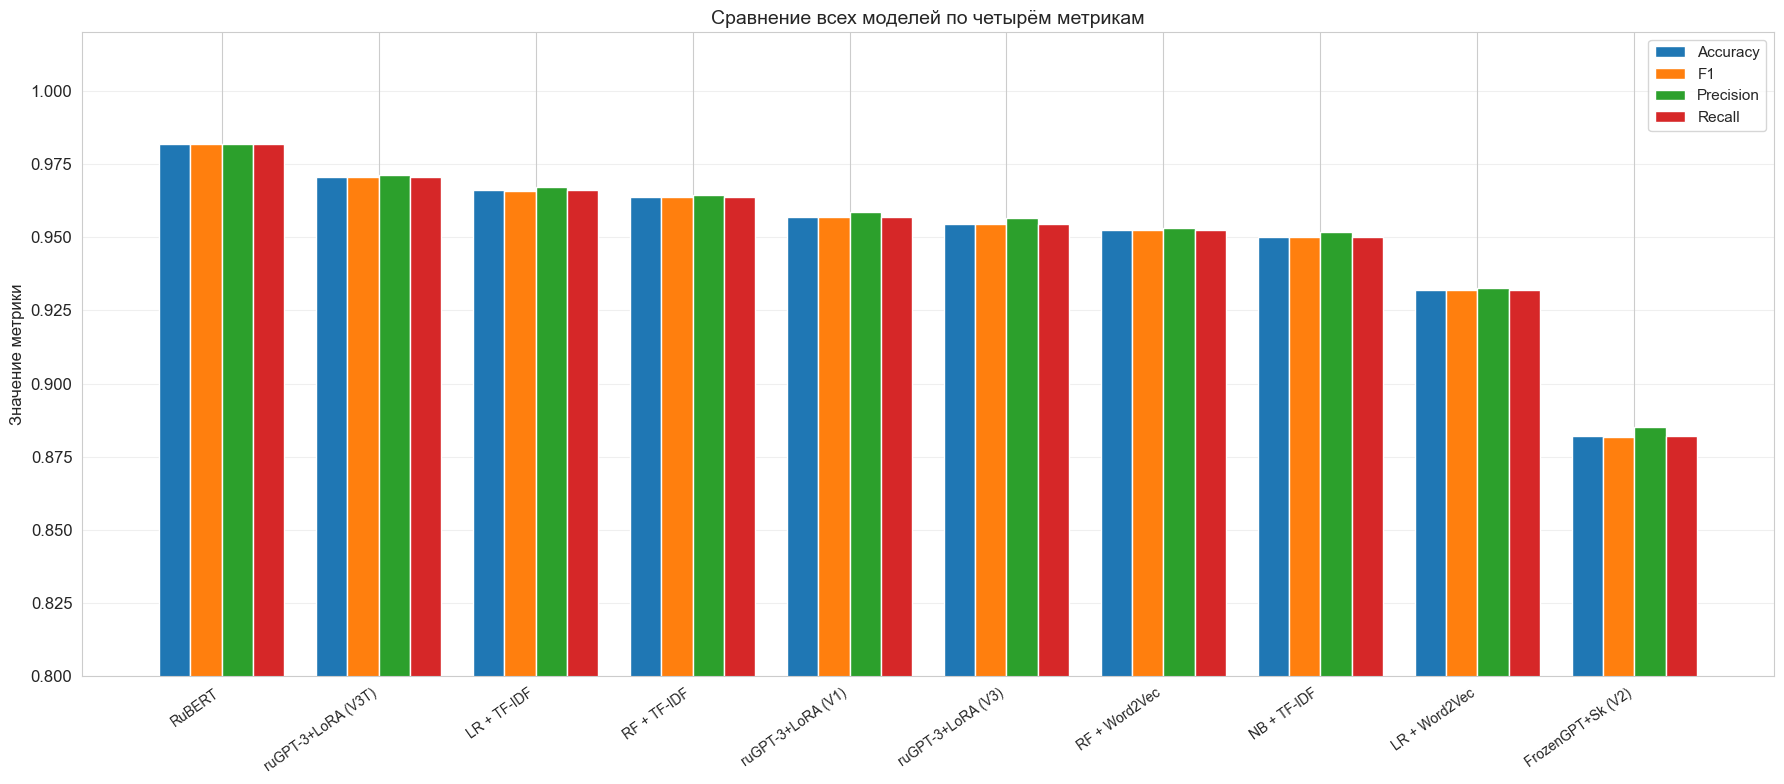

In [9]:
# Все 4 метрики — группированная столбчатая диаграмма
metrics_cols = ["Accuracy", "F1", "Precision", "Recall"]
df_plot = results_df.sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(18, 8))
x = np.arange(len(df_plot))
width = 0.2

for i, metric in enumerate(metrics_cols):
    bars = ax.bar(x + i * width, df_plot[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot["Модель"], rotation=35, ha="right", fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение всех моделей по четырём метрикам")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("assets/all_models_4metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Матрицы ошибок всех моделей

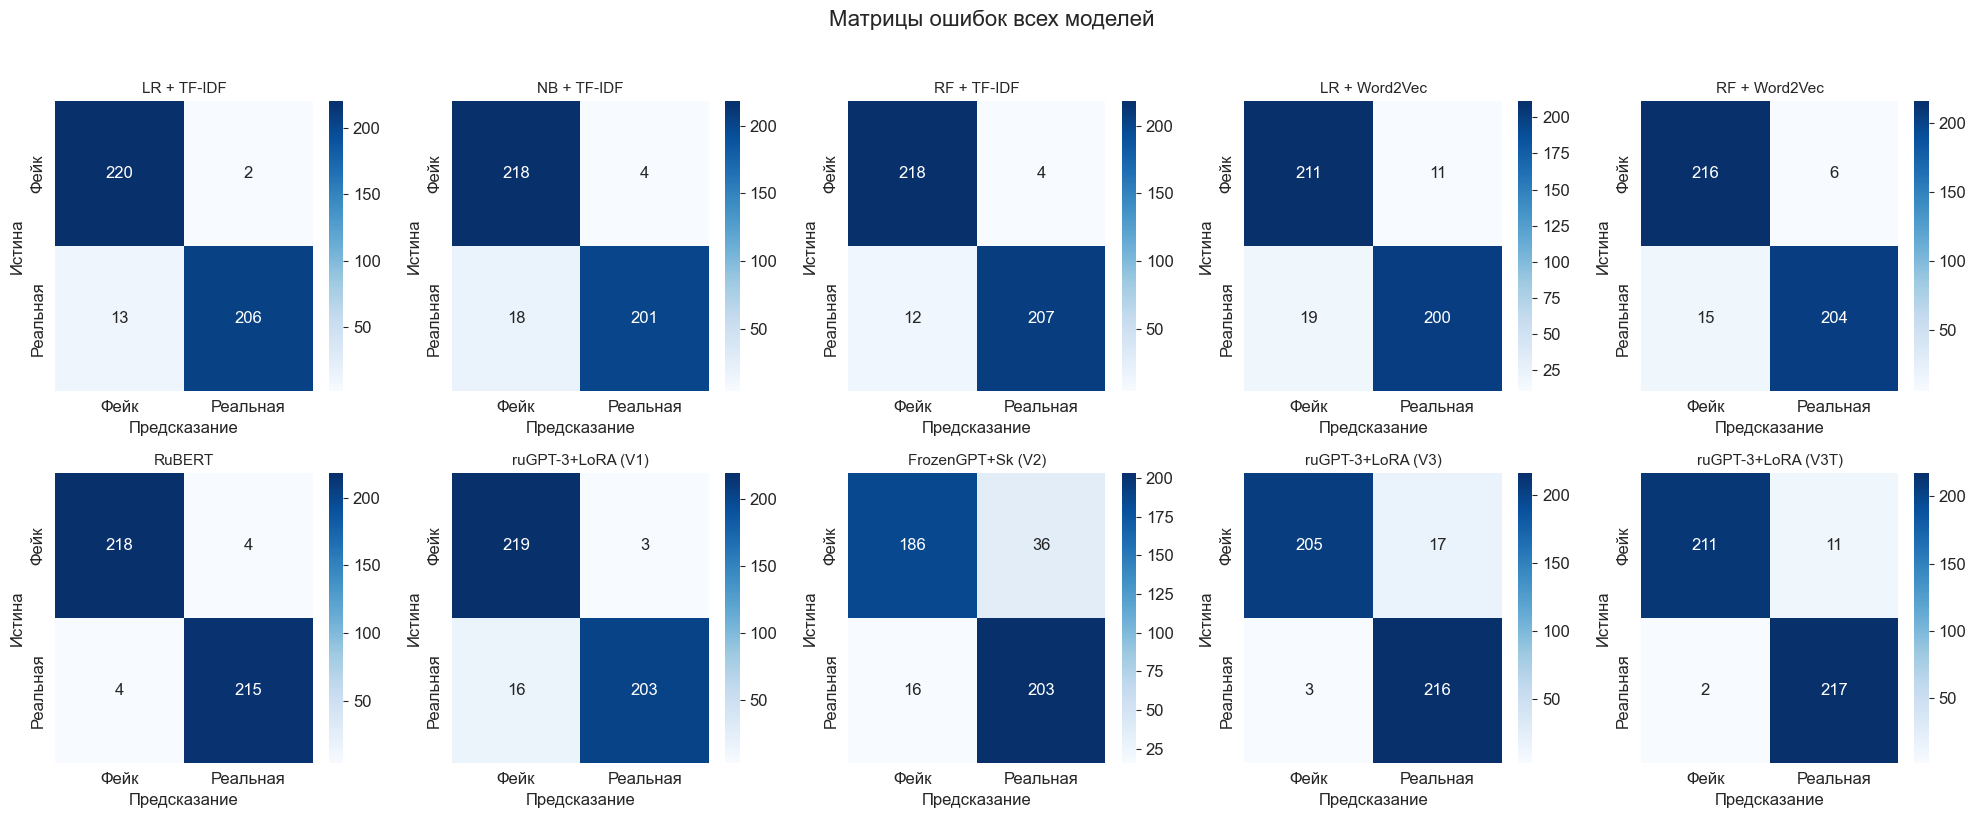

In [10]:
model_names = list(all_models.keys())
n_models = len(model_names)
n_cols = 5
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_true, all_models[name]["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Фейк", "Реальная"], yticklabels=["Фейк", "Реальная"])
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel("Истина")
    axes[i].set_xlabel("Предсказание")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Матрицы ошибок всех моделей", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("assets/all_models_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. ROC-кривые всех моделей

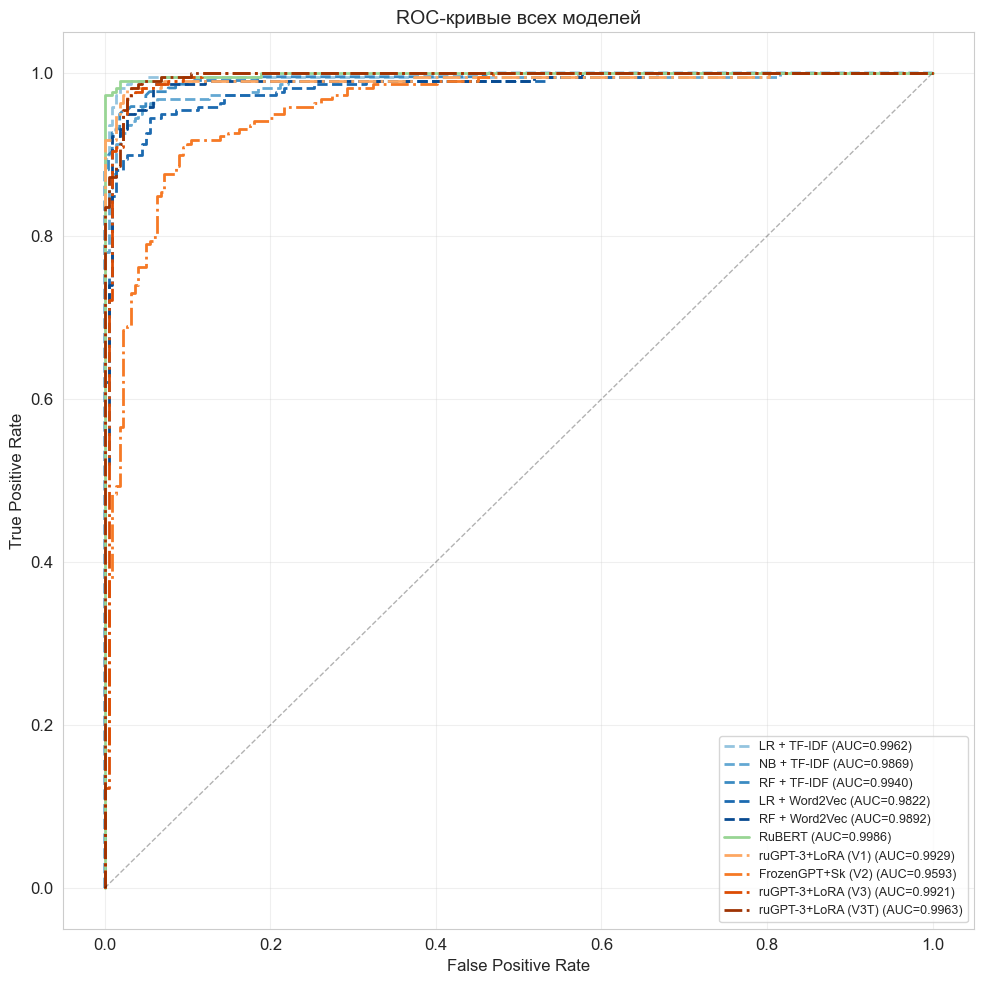

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

line_styles = {
    "Классическая": "--",
    "Трансформер": "-",
    "LLM": "-.",
}
cat_colors = {
    "Классическая": plt.cm.Blues,
    "Трансформер": plt.cm.Greens,
    "LLM": plt.cm.Oranges,
}

# Считаем индексы для цветов внутри каждой категории
cat_counts = {}
for name, d in all_models.items():
    cat = d["category"]
    cat_counts.setdefault(cat, 0)
    idx = cat_counts[cat]
    n_in_cat = sum(1 for v in all_models.values() if v["category"] == cat)

    fpr, tpr, _ = roc_curve(y_true, d["probs"])
    roc_auc = auc(fpr, tpr)

    cmap = cat_colors[cat]
    color = cmap(0.4 + 0.5 * idx / max(n_in_cat - 1, 1))
    ls = line_styles[cat]

    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f"{name} (AUC={roc_auc:.4f})")

    cat_counts[cat] += 1

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые всех моделей")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("assets/all_models_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Сравнение по категориям (радарная диаграмма)

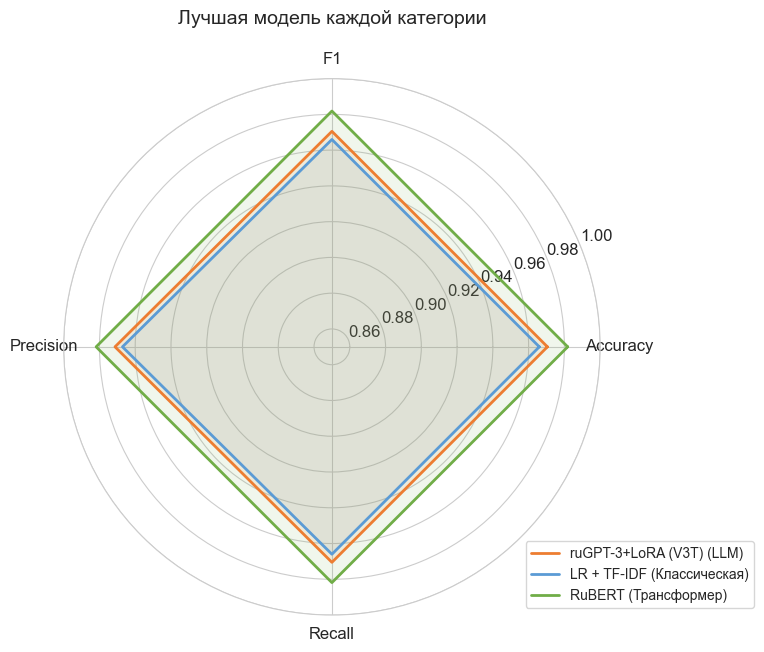

In [12]:
# Средние метрики по категориям
cat_avg = results_df.groupby("Категория")[["Accuracy", "F1", "Precision", "Recall"]].mean()

# Лучшая модель в каждой категории
cat_best = results_df.loc[results_df.groupby("Категория")["Accuracy"].idxmax()]
cat_best = cat_best.set_index("Категория")

# Радарная диаграмма для лучших моделей каждой категории
categories_radar = ["Accuracy", "F1", "Precision", "Recall"]
N = len(categories_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

cat_colors_flat = {"Классическая": "#5B9BD5", "Трансформер": "#70AD47", "LLM": "#ED7D31"}

for cat_name in cat_best.index:
    row = cat_best.loc[cat_name]
    values = [row[m] for m in categories_radar]
    values += values[:1]
    model_label = f"{row['Модель']} ({cat_name})"
    ax.plot(angles, values, linewidth=2, label=model_label, color=cat_colors_flat[cat_name])
    ax.fill(angles, values, alpha=0.1, color=cat_colors_flat[cat_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=12)
ax.set_ylim(0.85, 1.0)
ax.set_title("Лучшая модель каждой категории", fontsize=14, pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.3, 0), fontsize=10)

plt.tight_layout()
plt.savefig("assets/best_models_radar.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Детальное сравнение: RuBERT vs LLM V3 (ruGPT-3 + LoRA Max)

Две лучшие модели проекта — RuBERT (fine-tuned) и ruGPT-3 + LoRA Max (V3). Ниже — их подробное сравнение.

In [13]:
# Метрики бок о бок
print("=" * 60)
print("RuBERT vs LLM V3: Метрики на тестовой выборке")
print("=" * 60)

compare_rows = []
for name, preds in [("RuBERT", preds_rubert), ("ruGPT-3+LoRA V3", preds_v3)]:
    compare_rows.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_true, preds),
        "F1": f1_score(y_true, preds, average="weighted"),
        "Precision": precision_score(y_true, preds, average="weighted"),
        "Recall": recall_score(y_true, preds, average="weighted"),
    })

compare_df = pd.DataFrame(compare_rows).set_index("Модель")
print(compare_df.to_string(float_format=lambda x: f"{x:.4f}"))
print()

# Classification report
for name, preds in [("RuBERT", preds_rubert), ("ruGPT-3+LoRA V3", preds_v3)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_true, preds, target_names=["Фейк", "Реальная"], digits=4))

RuBERT vs LLM V3: Метрики на тестовой выборке
                 Accuracy     F1  Precision  Recall
Модель                                             
RuBERT             0.9819 0.9819     0.9819  0.9819
ruGPT-3+LoRA V3    0.9546 0.9546     0.9565  0.9546


--- RuBERT ---
              precision    recall  f1-score   support

        Фейк     0.9820    0.9820    0.9820       222
    Реальная     0.9817    0.9817    0.9817       219

    accuracy                         0.9819       441
   macro avg     0.9819    0.9819    0.9819       441
weighted avg     0.9819    0.9819    0.9819       441


--- ruGPT-3+LoRA V3 ---
              precision    recall  f1-score   support

        Фейк     0.9856    0.9234    0.9535       222
    Реальная     0.9270    0.9863    0.9558       219

    accuracy                         0.9546       441
   macro avg     0.9563    0.9549    0.9546       441
weighted avg     0.9565    0.9546    0.9546       441



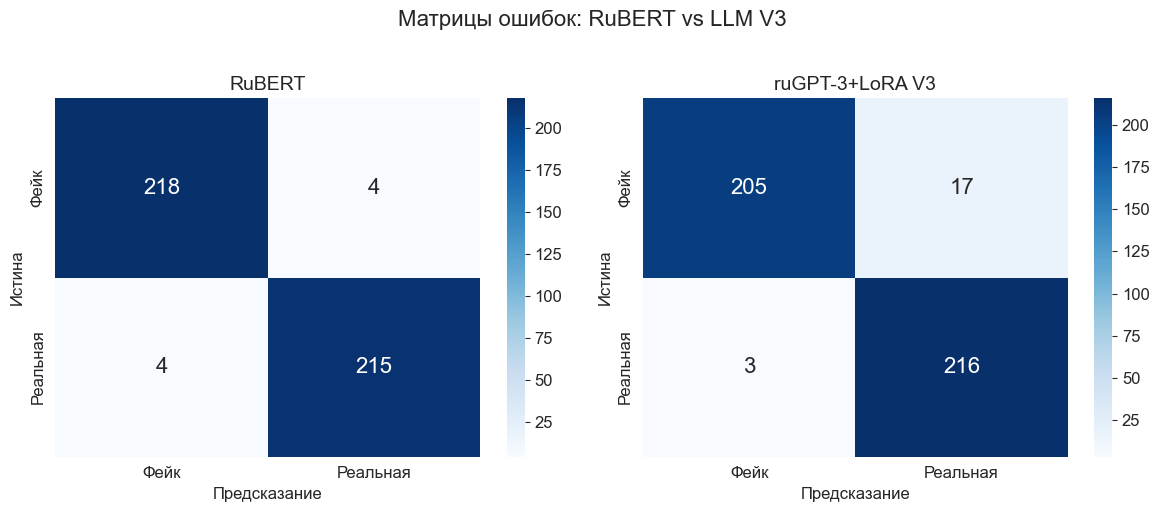

In [14]:
# Матрицы ошибок бок о бок
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, preds in [(axes[0], "RuBERT", preds_rubert), (axes[1], "ruGPT-3+LoRA V3", preds_v3)]:
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Фейк", "Реальная"], yticklabels=["Фейк", "Реальная"],
                annot_kws={"size": 16})
    ax.set_title(name, fontsize=14)
    ax.set_ylabel("Истина", fontsize=12)
    ax.set_xlabel("Предсказание", fontsize=12)

plt.suptitle("Матрицы ошибок: RuBERT vs LLM V3", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("assets/rubert_vs_v3_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

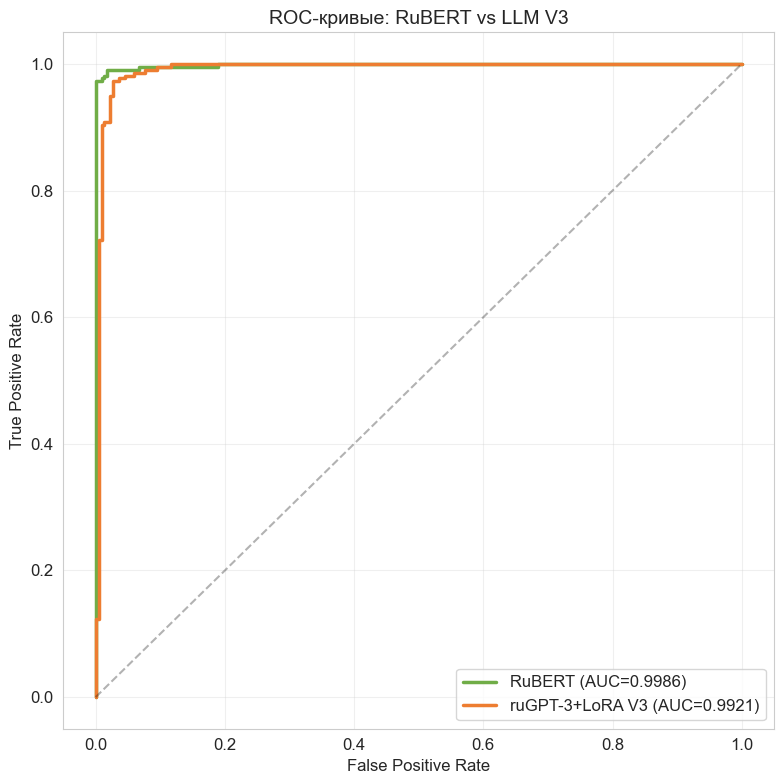

In [15]:
# ROC-кривые: RuBERT vs LLM V3
fig, ax = plt.subplots(figsize=(8, 8))

fpr_rb, tpr_rb, _ = roc_curve(y_true, probs_rubert)
auc_rb = auc(fpr_rb, tpr_rb)
ax.plot(fpr_rb, tpr_rb, linewidth=2.5, color="#70AD47", label=f"RuBERT (AUC={auc_rb:.4f})")

fpr_v3, tpr_v3, _ = roc_curve(y_true, probs_v3)
auc_v3 = auc(fpr_v3, tpr_v3)
ax.plot(fpr_v3, tpr_v3, linewidth=2.5, color="#ED7D31", label=f"ruGPT-3+LoRA V3 (AUC={auc_v3:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC-кривые: RuBERT vs LLM V3", fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("assets/rubert_vs_v3_roc.png", dpi=150, bbox_inches="tight")
plt.show()

Согласованность предсказаний:
  Совпадают:    419 (95.0%)
  Расходятся:   22 (5.0%)

Из 22 расхождений:
  RuBERT прав, V3 ошибся:  17
  V3 прав, RuBERT ошибся:  5
  Оба ошиблись:             0


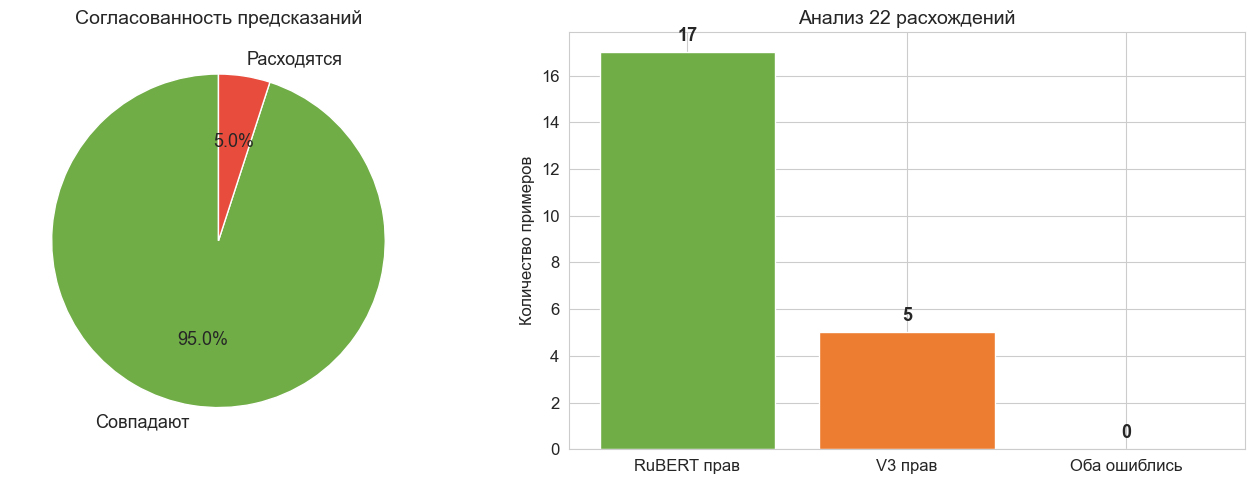

In [16]:
# Анализ согласованности предсказаний RuBERT и V3
agree = (preds_rubert == preds_v3).sum()
disagree = len(preds_rubert) - agree

print(f"Согласованность предсказаний:")
print(f"  Совпадают:    {agree} ({agree/len(preds_rubert):.1%})")
print(f"  Расходятся:   {disagree} ({disagree/len(preds_rubert):.1%})")
print()

# Где расходятся?
mask_disagree = preds_rubert != preds_v3
rubert_right = ((preds_rubert == y_true) & mask_disagree).sum()
v3_right = ((preds_v3 == y_true) & mask_disagree).sum()
both_wrong = (mask_disagree & (preds_rubert != y_true) & (preds_v3 != y_true)).sum()

print(f"Из {disagree} расхождений:")
print(f"  RuBERT прав, V3 ошибся:  {rubert_right}")
print(f"  V3 прав, RuBERT ошибся:  {v3_right}")
print(f"  Оба ошиблись:             {both_wrong}")

# Визуализация согласованности
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie([agree, disagree], labels=["Совпадают", "Расходятся"],
            autopct="%1.1f%%", colors=["#70AD47", "#E74C3C"], startangle=90,
            textprops={"fontsize": 13})
axes[0].set_title("Согласованность предсказаний", fontsize=14)

# Breakdown расхождений
labels = ["RuBERT прав", "V3 прав", "Оба ошиблись"]
values = [rubert_right, v3_right, both_wrong]
bar_colors = ["#70AD47", "#ED7D31", "#E74C3C"]
axes[1].bar(labels, values, color=bar_colors)
axes[1].set_title(f"Анализ {disagree} расхождений", fontsize=14)
axes[1].set_ylabel("Количество примеров")
for i, v in enumerate(values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("assets/rubert_vs_v3_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

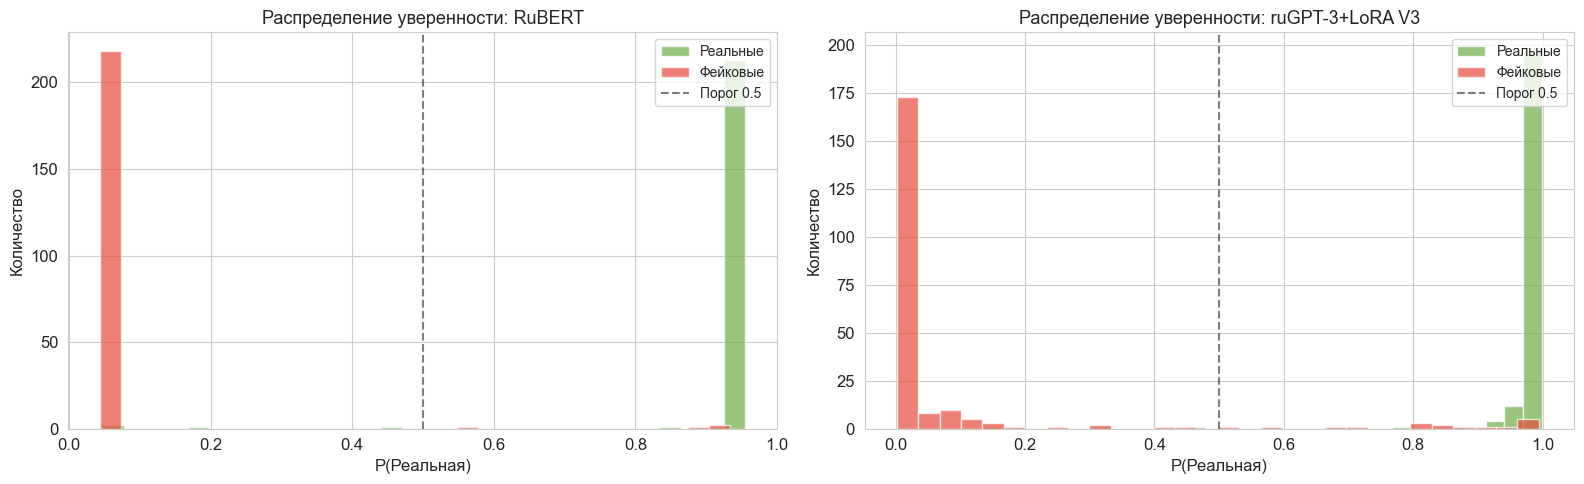

In [17]:
# Распределение уверенности (вероятности класса 1) для RuBERT и V3
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name, probs in [(axes[0], "RuBERT", probs_rubert), (axes[1], "ruGPT-3+LoRA V3", probs_v3)]:
    mask_real = y_true == 1
    mask_fake = y_true == 0
    ax.hist(probs[mask_real], bins=30, alpha=0.7, label="Реальные", color="#70AD47", edgecolor="white")
    ax.hist(probs[mask_fake], bins=30, alpha=0.7, label="Фейковые", color="#E74C3C", edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Порог 0.5")
    ax.set_xlabel("P(Реальная)", fontsize=12)
    ax.set_ylabel("Количество", fontsize=12)
    ax.set_title(f"Распределение уверенности: {name}", fontsize=13)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("assets/rubert_vs_v3_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Сохранение результатов

In [18]:
# Сохраняем сводную таблицу в CSV
results_df.to_csv("assets/all_models_comparison.csv", index=False)
print("Сохранено: assets/all_models_comparison.csv")

# Сохраняем детальное сравнение RuBERT vs V3
compare_df.to_csv("assets/rubert_vs_v3_comparison.csv")
print("Сохранено: assets/rubert_vs_v3_comparison.csv")

print("\nСохранённые графики:")
saved = [
    "assets/all_models_accuracy_f1.png",
    "assets/all_models_4metrics.png",
    "assets/all_models_confusion_matrices.png",
    "assets/all_models_roc.png",
    "assets/best_models_radar.png",
    "assets/rubert_vs_v3_confusion.png",
    "assets/rubert_vs_v3_roc.png",
    "assets/rubert_vs_v3_agreement.png",
    "assets/rubert_vs_v3_confidence.png",
]
for s in saved:
    print(f"  {s}")

Сохранено: assets/all_models_comparison.csv
Сохранено: assets/rubert_vs_v3_comparison.csv

Сохранённые графики:
  assets/all_models_accuracy_f1.png
  assets/all_models_4metrics.png
  assets/all_models_confusion_matrices.png
  assets/all_models_roc.png
  assets/best_models_radar.png
  assets/rubert_vs_v3_confusion.png
  assets/rubert_vs_v3_roc.png
  assets/rubert_vs_v3_agreement.png
  assets/rubert_vs_v3_confidence.png
